## Polytope Extremes-DT Feature Extraction Bounding Box example notebook

This notebook shows how to use earthkit-data and earthkit-plots to pull destination-earth data from LUMI and plot it using earthkit-plots.


Before running the notebook you need to set up your credentials. See the main readme of this repository for different ways to do this or use the following cells to authenticate.

You will need to generate your credentials using the desp-authentication.py script.

This can be run as follows:

In [ ]:
%%capture cap
%run ../../desp-authentication.py

This will generate a token that can then be used by earthkit and polytope.

In [ ]:
output_1 = cap.stdout.split('}\n')
access_token = output_1[-1][0:-1]

# Requirements
To run this notebook install the following:
* pip install earthkit-data
* pip install earthkit-plots
* pip install cf-units         (Optional for unit conversion in maps)

In [ ]:
import earthkit.data
import earthkit.plots

In [ ]:
# Set True if you want to make a live request for the data, or false if you want to use the cached grib file
# Defaults to making a live data request. Set to false to use the cached GRIB file instead.
import os

LIVE_REQUEST = os.getenv("LIVE_REQUEST", "true").lower() == "true"
LIVE_REQUEST = False

In [ ]:
request = {
    "dataset": "extremes-dt",
    "class": "d1",
    "stream": "oper",
    "type": "fc",
    "date": "-14",
    "time": "0000",
    "levtype": "pl",
    "expver": "0001",
    "param": "131",
    "step": "0",
    "feature": {
        "type": "verticalprofile",
        "points": [[38.9, -9.1]],
        "range" : {
            "start": "0",
            "end": "1000",
        }
    },
}

In [ ]:
data_file = "../data/extremes-dt-earthkit-example-fe-verticalprofile.covjson"
if LIVE_REQUEST:
    data = earthkit.data.from_source("polytope", "destination-earth", request, address="polytope.lumi.apps.dte.destination-earth.eu", stream=False)
    with open(data_file, "w") as _f:
        data.to_target("file", _f)
else:
    data = earthkit.data.from_source("file", data_file) 

In [ ]:
# Convert data to xarray
da = data.to_xarray()
da

<xarray.Dataset> Size: 448B
Dimensions:    (latitude: 1, longitude: 1, number: 1, datetime: 1, time: 1,
                levelist: 21)
Coordinates:
  * latitude   (latitude) float64 8B 38.9
  * longitude  (longitude) float64 8B 350.9
  * number     (number) int64 8B 0
  * datetime   (datetime) <U20 80B '2025-08-08T00:00:00Z'
  * time       (time) int64 8B 0
  * levelist   (levelist) int64 168B 1 2 3 5 7 10 ... 400 500 700 850 925 1000
Data variables:
    u          (latitude, longitude, number, datetime, time, levelist) float64 168B ...
Attributes:
    class:          d1
    dataset:        extremes-dt
    Forecast date:  2025-08-08T00:00:00Z
    expver:         0001
    levelist:       1
    levtype:        pl
    stream:         oper
    type:           fc
    number:         0

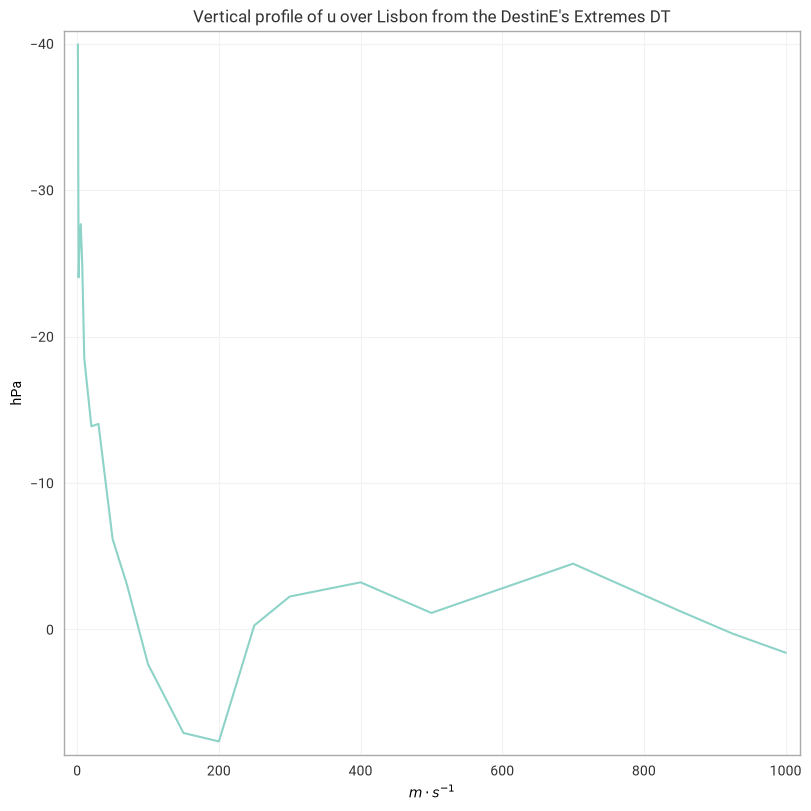

In [ ]:
chart = earthkit.plots.Subplot(figsize=(8, 8))

chart.line(da, x="levelist")
chart.title("Vertical profile of {variable_name} over Lisbon from the DestinE's Extremes DT")
chart.ylabel("hPa")
chart.xlabel("{units}")

chart.ax.invert_yaxis()

chart.show()